In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier,HistGradientBoostingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [3]:
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [4]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.135710
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.342587
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


In [6]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [7]:
wine['quality_label'].value_counts()

quality_label
0    1382
1     217
Name: count, dtype: int64

Dataset is highly imbalanced, that is why we will get high accuracy but low F1 score in upcoming models.

In [13]:
X = wine.drop(['quality', 'quality_label'], axis=1)
y = wine['quality_label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [15]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [16]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt))

lr = LogisticRegression(random_state=42, max_iter=1000) 
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred_lr))

kn = KNeighborsClassifier()
kn.fit(X_train_scaled, y_train)
y_pred_kn = kn.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_kn))
print("KNN F1 Score:", f1_score(y_test, y_pred_kn))

Decision Tree Accuracy: 0.90625
Decision Tree F1 Score: 0.6666666666666666
Logistic Regression Accuracy: 0.89375
Logistic Regression F1 Score: 0.48484848484848486
KNN Accuracy: 0.89375
KNN F1 Score: 0.5142857142857142


In [17]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'KNN'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_kn)],
    'F1 Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_kn)]
})
results.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,F1 Score
0,Decision Tree,0.90625,0.666667
2,KNN,0.89375,0.514286
1,Logistic Regression,0.89375,0.484848


In [20]:
bg = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42,oob_score=True)
bg.fit(X_train_scaled, y_train)
y_pred_bg = bg.predict(X_test_scaled)
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bg))
print("Bagging F1 Score:", f1_score(y_test, y_pred_bg))
rf = RandomForestClassifier(n_estimators=100, random_state=42,oob_score=True)
rf.fit(X_train_scaled, y_train) 
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

Bagging Accuracy: 0.9375
Bagging F1 Score: 0.7368421052631579
Random Forest Accuracy: 0.9375
Random Forest F1 Score: 0.7142857142857143


Bagging has higher accuracy and F1 score than single Decision Tree because it uses bootstrap sampling and multiple Decision trees, and after that it takes most efficient tree's results.

C:\Users\user\AppData\Local\Temp\ipykernel_5676\2370659656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


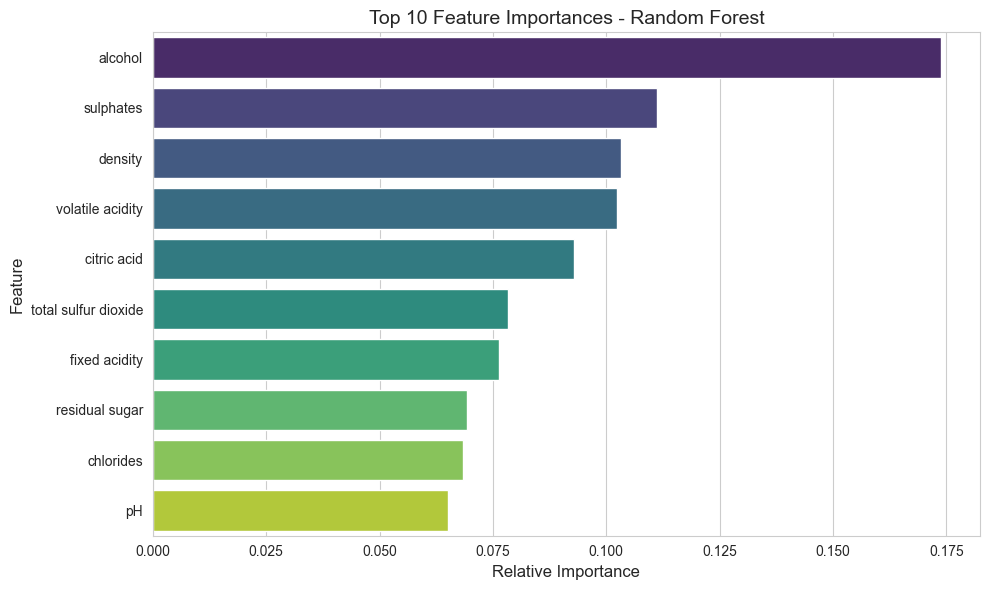

Top 3 most important features:
      Feature  Importance
10    alcohol    0.173743
9   sulphates    0.111262
7     density    0.103162


In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=X_train.columns.to_series().reset_index(drop=True).to_frame(name='Feature').assign(Importance=rf.feature_importances_).sort_values(by='Importance', ascending=False).head(10),
    palette='viridis' 
)

plt.title('Top 10 Feature Importances - Random Forest', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Print the top 3 for easy reading
print("Top 3 most important features:")
print(X_train.columns.to_series().reset_index(drop=True).to_frame(name='Feature').assign(Importance=rf.feature_importances_).sort_values(by='Importance', ascending=False).head(3))

Random Forest uses multiple Decision Trees for classification and in every tree Random Forest chooses some features and it makes trees more diverse and reduces variance

In [23]:
ab = AdaBoostClassifier(n_estimators=100, random_state=42)
ab.fit(X_train_scaled, y_train)
y_pred_ab = ab.predict(X_test_scaled)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ab))
print("AdaBoost F1 Score:", f1_score(y_test, y_pred_ab))

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting F1 Score:", f1_score(y_test, y_pred_gb))

hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train_scaled, y_train)
y_pred_hgb = hgb.predict(X_test_scaled)
print("HistGradient Boosting Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("HistGradient Boosting F1 Score:", f1_score(y_test, y_pred_hgb))

AdaBoost Accuracy: 0.89375
AdaBoost F1 Score: 0.43333333333333335
Gradient Boosting Accuracy: 0.915625
Gradient Boosting F1 Score: 0.6197183098591549
HistGradient Boosting Accuracy: 0.94375
HistGradient Boosting F1 Score: 0.7631578947368421


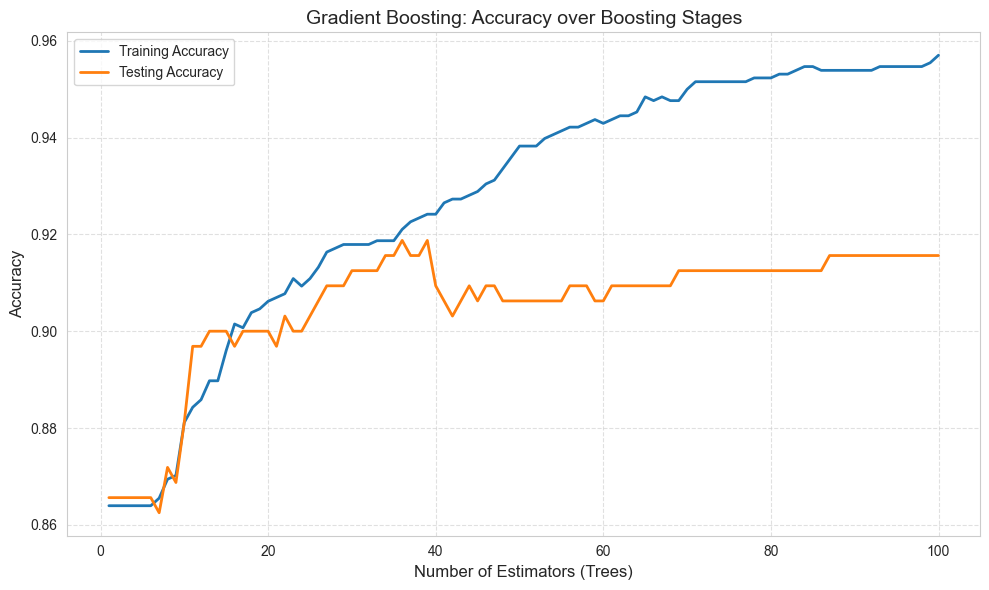

In [24]:
train_scores = []
test_scores = []

for y_train_pred in gb.staged_predict(X_train_scaled):
    train_scores.append(accuracy_score(y_train, y_train_pred))

for y_test_pred in gb.staged_predict(X_test_scaled):
    test_scores.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), train_scores, label='Training Accuracy', linewidth=2)
plt.plot(range(1, 101), test_scores, label='Testing Accuracy', linewidth=2)

plt.title('Gradient Boosting: Accuracy over Boosting Stages', fontsize=14)
plt.xlabel('Number of Estimators (Trees)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Gradient Boosting is much more accurate in terms of accuracy and F1 score compared to AdaBoost. If we need pace-centered and computationally-low model, then we can choose AdaBoost but if accuracy is more important than computational cost and time consume, then, definitely, our choice should be Gradient Boosting

In [25]:
vc = VotingClassifier(estimators=[('hgb', hgb), ('bg', bg), ('rf', rf)], voting='soft')
vc.fit(X_train_scaled, y_train)
y_pred_vc = vc.predict(X_test_scaled)
print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vc))
print("Voting Classifier F1 Score:", f1_score(y_test, y_pred_vc))

Voting Classifier Accuracy: 0.946875
Voting Classifier F1 Score: 0.7733333333333333


In [26]:
sc = StackingClassifier(estimators=[('hgb', hgb), ('bg', bg), ('rf', rf)], final_estimator=LogisticRegression(), cv=5)
sc.fit(X_train_scaled, y_train) 
y_pred_sc = sc.predict(X_test_scaled)
print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_sc))
print("Stacking Classifier F1 Score:", f1_score(y_test, y_pred_sc))

Stacking Classifier Accuracy: 0.946875
Stacking Classifier F1 Score: 0.7605633802816901


In [29]:
all = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'KNN', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'HistGradient Boosting', 'Voting Classifier', 'Stacking Classifier'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_kn), accuracy_score(y_test, y_pred_bg), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_ab), accuracy_score(y_test, y_pred_gb), accuracy_score(y_test, y_pred_hgb), accuracy_score(y_test, y_pred_vc), accuracy_score(y_test, y_pred_sc)],
    'F1 Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_kn), f1_score(y_test, y_pred_bg), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_ab), f1_score(y_test, y_pred_gb), f1_score(y_test, y_pred_hgb), f1_score(y_test, y_pred_vc), f1_score(y_test, y_pred_sc)]
}).sort_values(by='F1 Score', ascending=False)

In [30]:
all

,Model,Accuracy,F1 Score
8,Voting Classifier,0.946875,0.773333
7,HistGradient Boosting,0.943750,0.763158
9,Stacking Classifier,0.946875,0.760563
3,Bagging,0.937500,0.736842
4,Random Forest,0.937500,0.714286
0,Decision Tree,0.906250,0.666667
6,Gradient Boosting,0.915625,0.619718
2,KNN,0.893750,0.514286
1,Logistic Regression,0.893750,0.484848
5,AdaBoost,0.893750,0.433333


Voting classifier did the best in this dataset. I would recommend voting classifier for real-life wine quality prediction system. main trade-off of ensembles' are computational cost and time-consuming complexity.

Our models showed improvement even on a single model is significant.